# Final Transfer-Aware Model Comparison

This notebook visualizes artifacts produced by
`scripts/final_transfer_experiment.py` (and refreshed by
`scripts/final_transfer_repick.py`).

It **does not retrain** any model — it only reads CSV / JSON outputs
from `artifacts/final_transfer/`.

Sections:

1. Load artifacts + ranked model comparison table
2. Pooled ROC-AUC per model
3. LODO AUC per held-out dataset
4. LODO minimum AUC ranking
5. Domain (fingerprint) AUC comparison (lower is better)
6. VPN AUC vs Domain AUC scatter
7. Calibration curves
8. Confusion-matrix grid (top models)
9. Threshold stability
10. Anti-fingerprint feature importance
11. Final recommendation summary


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', context='notebook')
    HAS_SNS = True
except Exception:
    HAS_SNS = False

plt.rcParams['figure.dpi'] = 110

ROOT = Path('..').resolve()
ART  = ROOT / 'artifacts' / 'final_transfer'
REC  = ART  / 'recommended'

print('Artifact root :', ART, '->', 'EXISTS' if ART.exists() else 'MISSING')
print('Recommend dir :', REC, '->', 'EXISTS' if REC.exists() else 'MISSING')

Artifact root : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\final_transfer -> EXISTS
Recommend dir : C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\final_transfer\recommended -> EXISTS


## 1. Ranked model comparison (by `final_score`)

In [2]:
comp = pd.read_csv(ART / 'model_comparison.csv')
comp = comp.sort_values('final_score', ascending=False).reset_index(drop=True)
print(f'{len(comp)} model rows loaded.')
display_cols = [
    'model_id', 'feature_family', 'family', 'n_features',
    'pooled_auc', 'session_auc', 'lodo_min_auc', 'lodo_mean_auc',
    'domain_auc', 'embedding_domain_auc', 'domain_reduction',
    'fpr', 'ece', 'threshold_instability',
    'runtime_compatible', 'final_score',
]
display_cols = [c for c in display_cols if c in comp.columns]
comp[display_cols].round(4).head(20)

46 model rows loaded.


,model_id,feature_family,family,n_features,pooled_auc,session_auc,lodo_min_auc,lodo_mean_auc,domain_auc,embedding_domain_auc,domain_reduction,fpr,ece,threshold_instability,runtime_compatible,final_score
0,dann_v2__lam1.0_enc64x32_do0.2_bn1_balnone,full_canonical,dann_v2,34,0.9787,0.9241,NaN,NaN,1.0,0.9999,0.0000,0.0190,0.0114,0.0000,True,0.9427
1,dann_v2__lam0.5_enc32x16_do0.2_bn1_balboth,full_canonical,dann_v2,34,0.9711,0.8977,NaN,NaN,1.0,0.9999,0.0001,0.0106,0.0857,0.0000,True,0.9338
2,dann_v2__lam0.1_enc128x64_do0.2_bn1_balboth,full_canonical,dann_v2,34,0.9785,0.9373,NaN,NaN,1.0,1.0000,-0.0000,0.0203,0.0705,0.0000,True,0.9243
3,dann_v2__lam1.0_enc32x16_do0.2_bn1_balboth,full_canonical,dann_v2,34,0.9656,0.8548,NaN,NaN,1.0,0.9999,0.0001,0.0108,0.0964,0.0000,True,0.9225
4,dann_v2__lam0.1_enc32x16_do0.2_bn1_balboth,full_canonical,dann_v2,34,0.9646,0.8878,NaN,NaN,1.0,0.9999,0.0001,0.0118,0.0801,0.0000,True,0.9225
5,dann_v2__lam0.5_enc64x32_do0.2_bn1_balboth,full_canonical,dann_v2,34,0.9618,0.9274,NaN,NaN,1.0,1.0000,-0.0000,0.0133,0.0555,0.0000,True,0.9204
6,dann_v2__lam2.0_enc64x32_do0.2_bn1_balboth,full_canonical,dann_v2,34,0.9659,0.8713,NaN,NaN,1.0,1.0000,0.0000,0.0098,0.1155,0.0000,True,0.9200
7,dann_v2__lam1.0_enc64x32_do0.2_bn1_baldomain,full_canonical,dann_v2,34,0.9526,0.8515,NaN,NaN,1.0,0.9999,0.0001,0.0128,0.0252,0.0000,True,0.9157
8,dann_v2__lam5.0_enc128x64_do0.2_bn1_balboth,full_canonical,dann_v2,34,0.9586,0.8911,NaN,NaN,1.0,0.9998,0.0001,0.0111,0.0813,0.0000,True,0.9148
9,dann_v2__lam0.5_enc128x64_do0.2_bn1_balboth,full_canonical,dann_v2,34,0.9663,0.8878,NaN,NaN,1.0,0.9999,0.0001,0.0181,0.0708,0.0000,True,0.9114


## 2. Pooled ROC-AUC per model

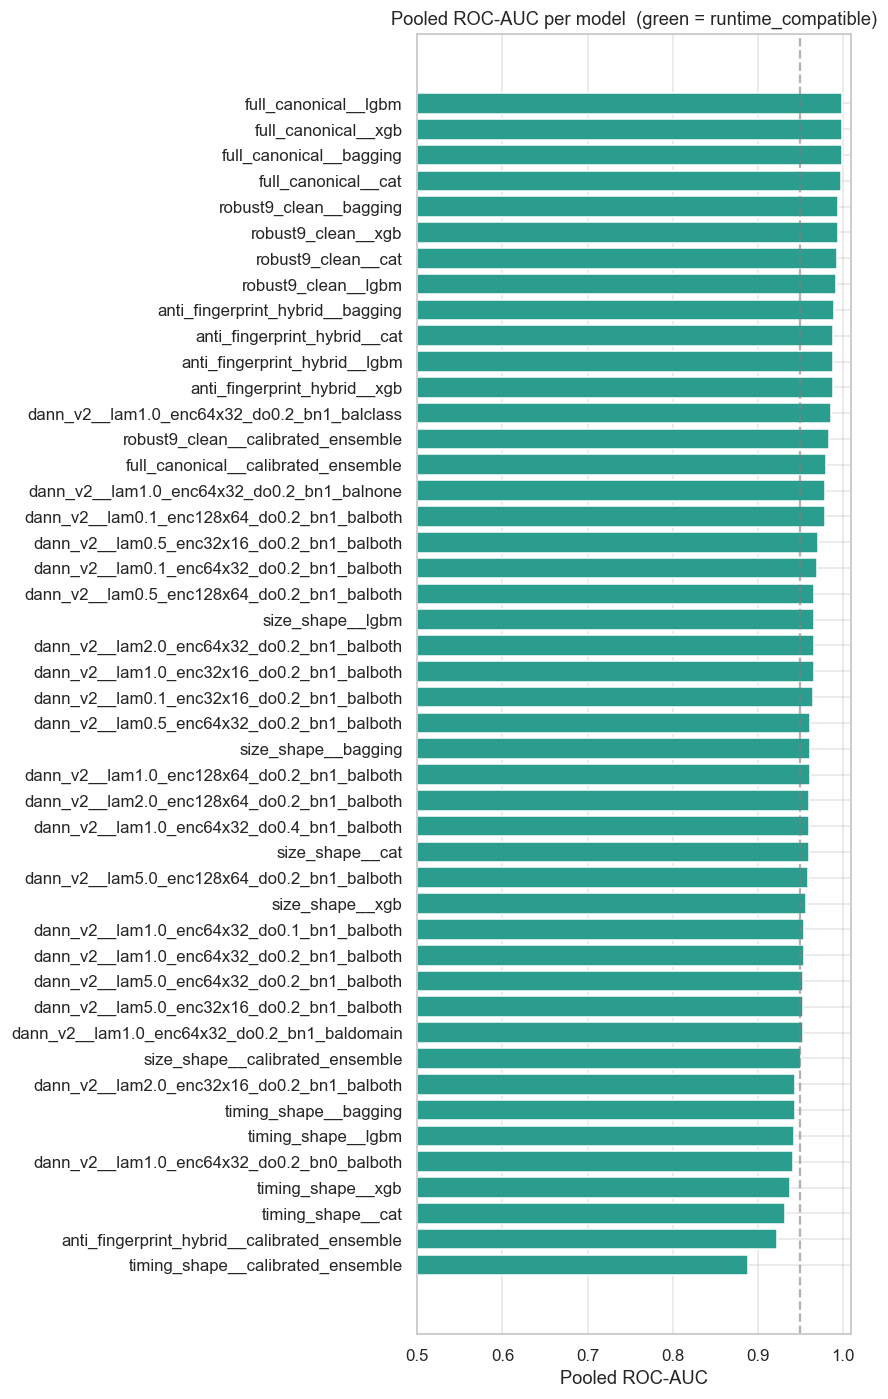

In [3]:
d = comp.sort_values('pooled_auc', ascending=True)
fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(d))))
colors = ['#2a9d8f' if rc else '#e76f51' for rc in d['runtime_compatible']]
ax.barh(d['model_id'], d['pooled_auc'], color=colors)
ax.set_xlabel('Pooled ROC-AUC')
ax.set_xlim(0.5, 1.01)
ax.set_title('Pooled ROC-AUC per model  (green = runtime_compatible)')
ax.axvline(0.95, ls='--', color='grey', alpha=.6)
plt.tight_layout(); plt.show()

## 3. LODO AUC per held-out dataset

LODO folds: ['lodo_iscx_auc', 'lodo_usbvpn_auc', 'lodo_vnat_auc']


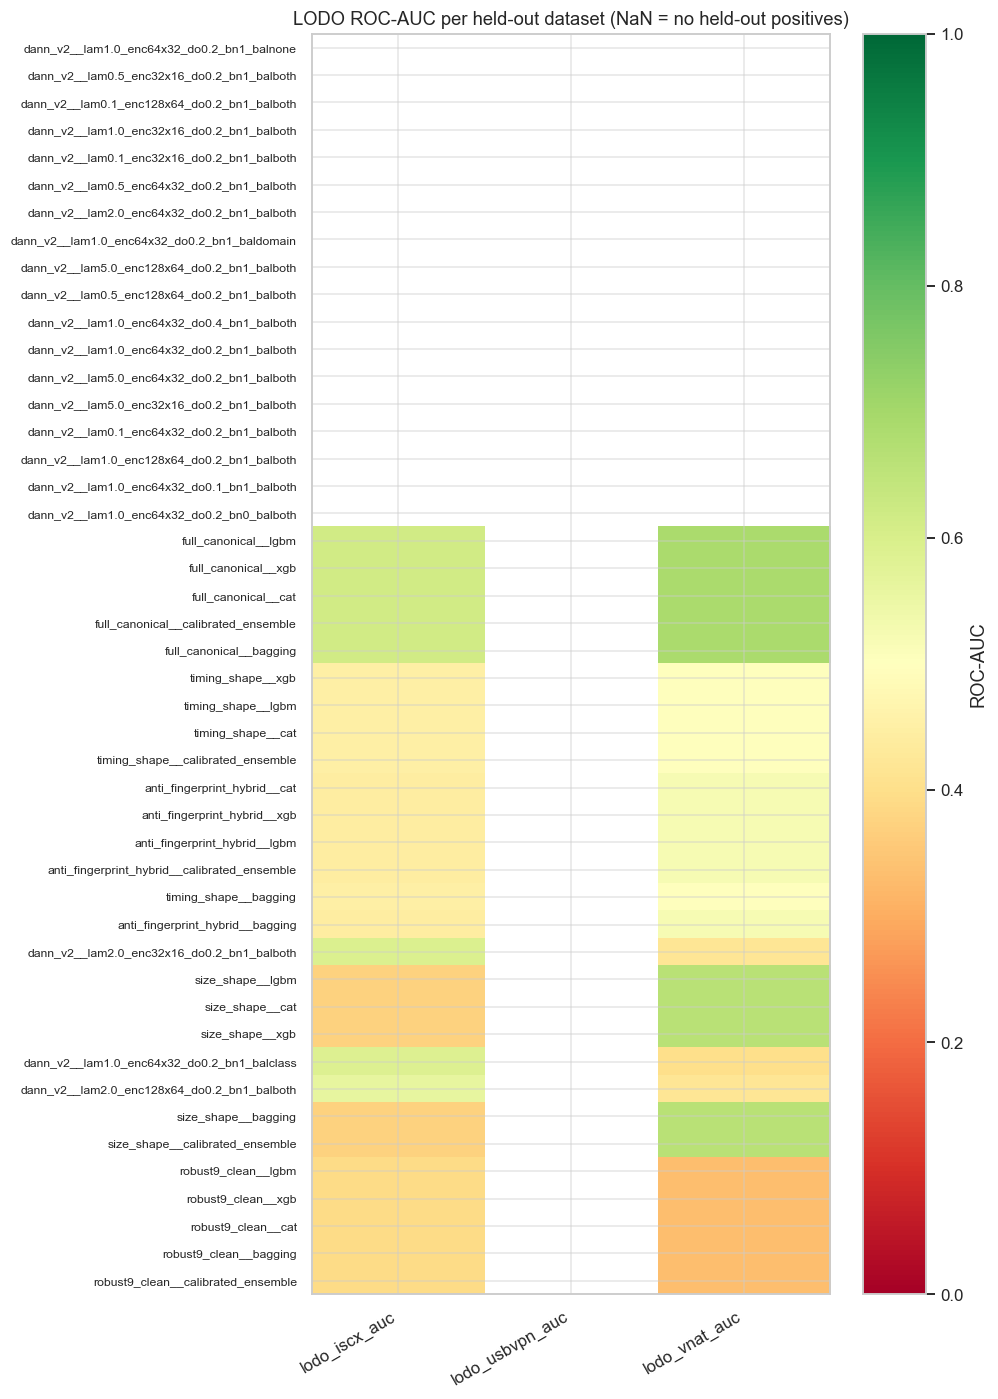

In [4]:
lodo_cols = [c for c in comp.columns if c.startswith('lodo_') and c.endswith('_auc')
              and c not in ('lodo_mean_auc', 'lodo_min_auc')]
print('LODO folds:', lodo_cols)

lodo = comp[['model_id'] + lodo_cols].copy().set_index('model_id')
fig, ax = plt.subplots(figsize=(9, max(4, 0.28 * len(lodo))))
im = ax.imshow(lodo.values.astype(float), aspect='auto', cmap='RdYlGn', vmin=0.0, vmax=1.0)
ax.set_yticks(range(len(lodo))); ax.set_yticklabels(lodo.index, fontsize=8)
ax.set_xticks(range(len(lodo_cols))); ax.set_xticklabels(lodo_cols, rotation=30, ha='right')
ax.set_title('LODO ROC-AUC per held-out dataset (NaN = no held-out positives)')
plt.colorbar(im, ax=ax, label='ROC-AUC')
plt.tight_layout(); plt.show()

## 4. LODO minimum AUC ranking (transfer hardness floor)

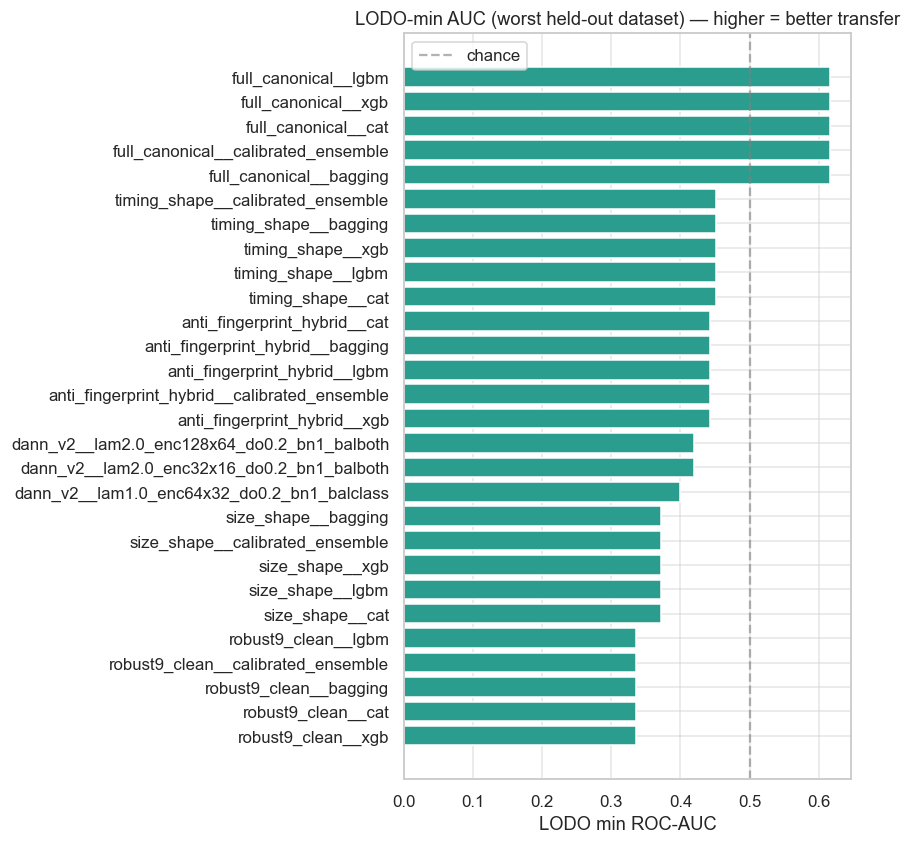

In [5]:
d = comp.dropna(subset=['lodo_min_auc']).sort_values('lodo_min_auc', ascending=True)
fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(d))))
colors = ['#2a9d8f' if rc else '#e76f51' for rc in d['runtime_compatible']]
ax.barh(d['model_id'], d['lodo_min_auc'], color=colors)
ax.axvline(0.5, color='grey', ls='--', alpha=.6, label='chance')
ax.set_xlabel('LODO min ROC-AUC')
ax.set_title('LODO-min AUC (worst held-out dataset) — higher = better transfer')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Domain (fingerprint) AUC — lower is better

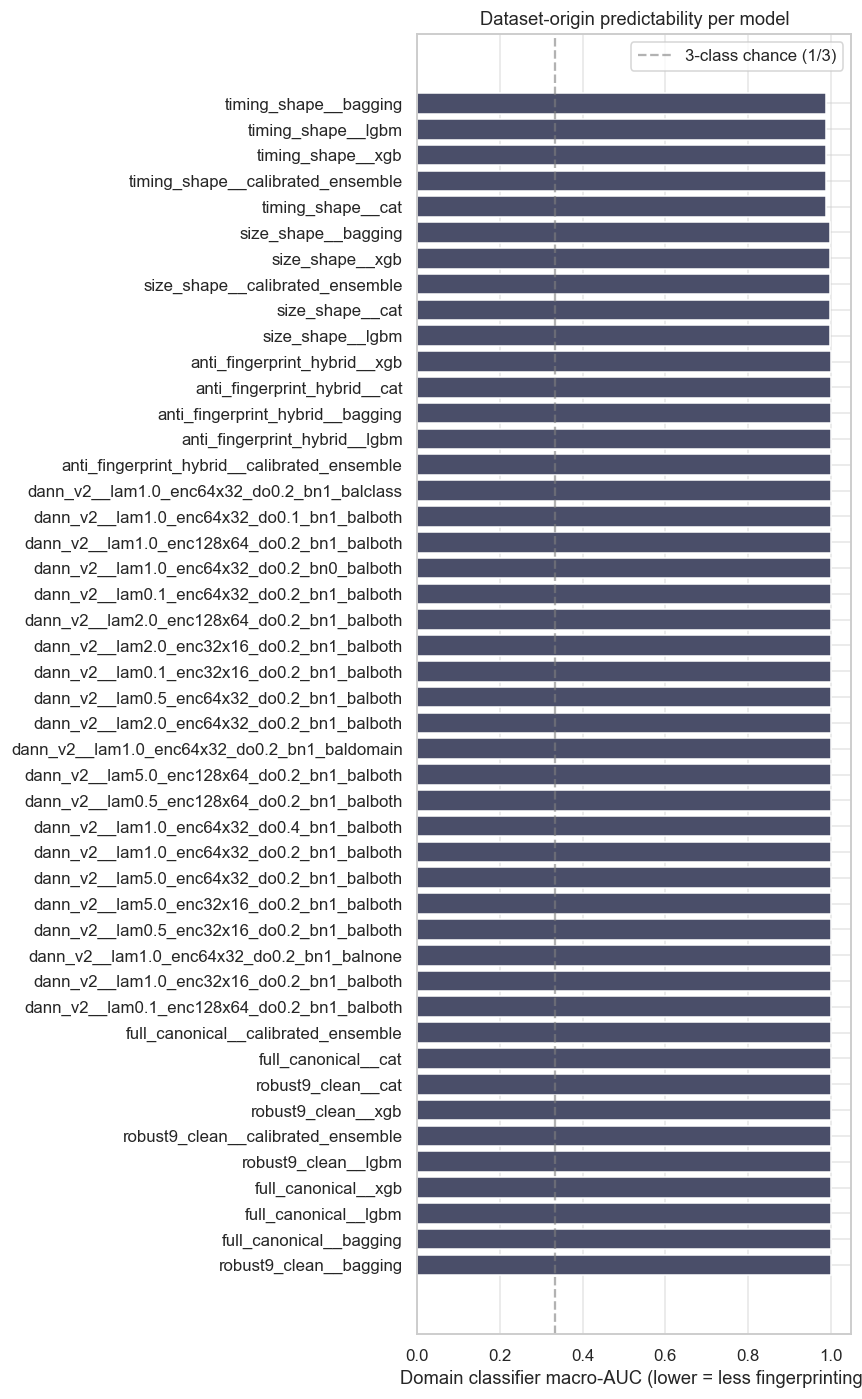

In [6]:
if 'domain_auc' not in comp.columns:
    print('domain_auc not in comparison table.')
else:
    d = comp.dropna(subset=['domain_auc']).sort_values('domain_auc', ascending=False)
    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(d))))
    ax.barh(d['model_id'], d['domain_auc'], color='#4a4e69')
    ax.axvline(1/3, color='grey', ls='--', alpha=.6, label='3-class chance (1/3)')
    ax.set_xlabel('Domain classifier macro-AUC (lower = less fingerprinting)')
    ax.set_title('Dataset-origin predictability per model')
    ax.legend(); plt.tight_layout(); plt.show()

## 6. VPN AUC vs Domain AUC scatter

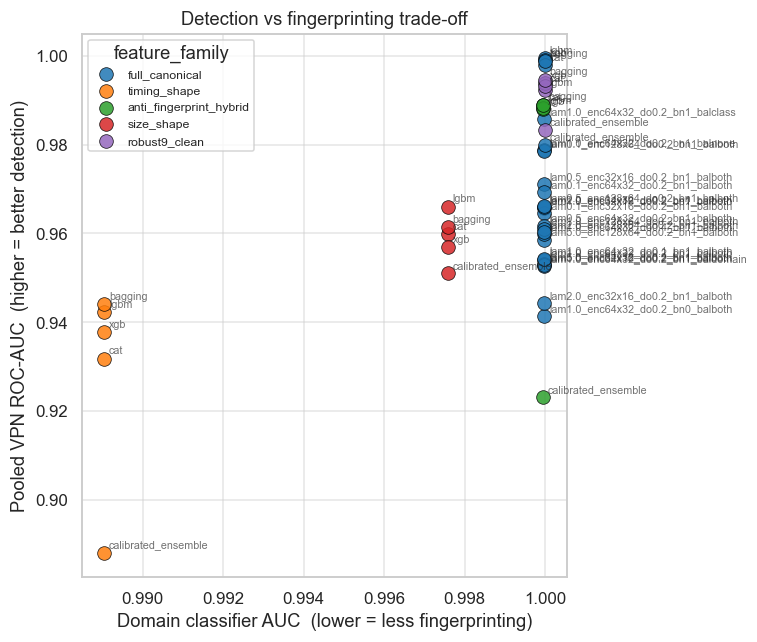

In [7]:
d = comp.dropna(subset=['pooled_auc', 'domain_auc']).copy()
fig, ax = plt.subplots(figsize=(7, 6))
fams = d['feature_family'].unique()
cmap = plt.cm.tab10
for i, ff in enumerate(fams):
    sub = d[d['feature_family'] == ff]
    ax.scatter(sub['domain_auc'], sub['pooled_auc'], s=80, alpha=.85,
               label=ff, color=cmap(i % 10),
               edgecolor='black', linewidth=.5)
for _, r in d.iterrows():
    ax.annotate(r['model_id'].split('__')[-1],
                (r['domain_auc'], r['pooled_auc']),
                fontsize=7, alpha=.65, xytext=(3, 3),
                textcoords='offset points')
ax.set_xlabel('Domain classifier AUC  (lower = less fingerprinting)')
ax.set_ylabel('Pooled VPN ROC-AUC  (higher = better detection)')
ax.set_title('Detection vs fingerprinting trade-off')
ax.legend(fontsize=8, title='feature_family')
plt.tight_layout(); plt.show()

## 7. Calibration curves

Plot calibration for the four recommended slots from their saved
`val_predictions.csv`. We use the validation split (the same split
used to fit calibrators / pick thresholds).

skip best_offline: cols=['capture_id', 'flow_id', 'dataset', 'label', 'prob_raw', 'prob_iso']
skip best_transfer: cols=['capture_id', 'flow_id', 'dataset', 'label', 'prob_raw', 'prob_iso']
skip best_low_fingerprint: cols=['capture_id', 'flow_id', 'dataset', 'label', 'prob_raw', 'prob_iso']
skip recommended_firewall: cols=['capture_id', 'flow_id', 'dataset', 'label', 'prob_raw', 'prob_iso']


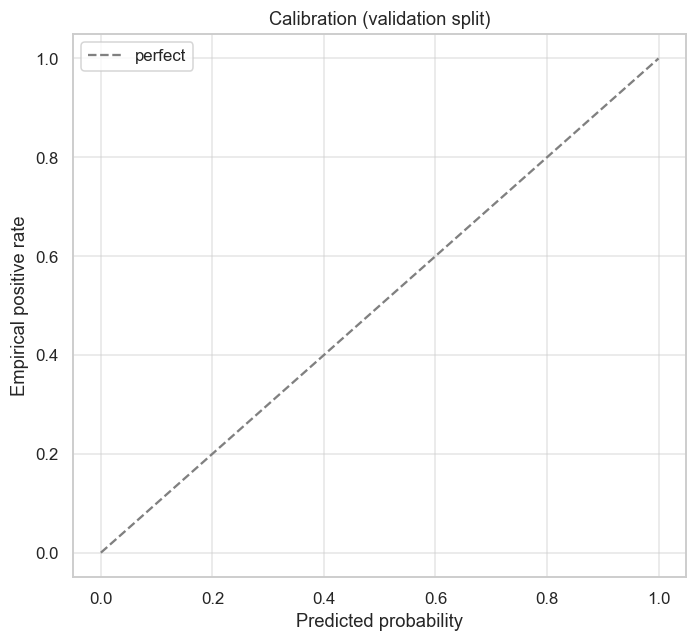

In [8]:
from sklearn.calibration import calibration_curve

slots = ['best_offline', 'best_transfer', 'best_low_fingerprint', 'recommended_firewall']
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot([0, 1], [0, 1], '--', color='grey', label='perfect')

for slot in slots:
    pf = REC / slot / 'val_predictions.csv'
    if not pf.exists():
        print(f'skip {slot}: no val_predictions')
        continue
    df = pd.read_csv(pf)
    prob_col = next((c for c in ('prob', 'prob_cal', 'score', 'y_prob', 'p') if c in df.columns), None)
    y_col    = next((c for c in ('y_true', 'label', 'y') if c in df.columns), None)
    if prob_col is None or y_col is None:
        print(f'skip {slot}: cols={list(df.columns)}')
        continue
    frac_pos, mean_pred = calibration_curve(df[y_col], df[prob_col], n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac_pos, marker='o', label=slot)

ax.set_xlabel('Predicted probability')
ax.set_ylabel('Empirical positive rate')
ax.set_title('Calibration (validation split)')
ax.legend(); plt.tight_layout(); plt.show()

## 8. Confusion-matrix grid

Top models by `final_score` evaluated on their saved
`test_predictions.csv` at the model-specific threshold stored
in `thresholds.json` (slot models) or 0.5 fallback.

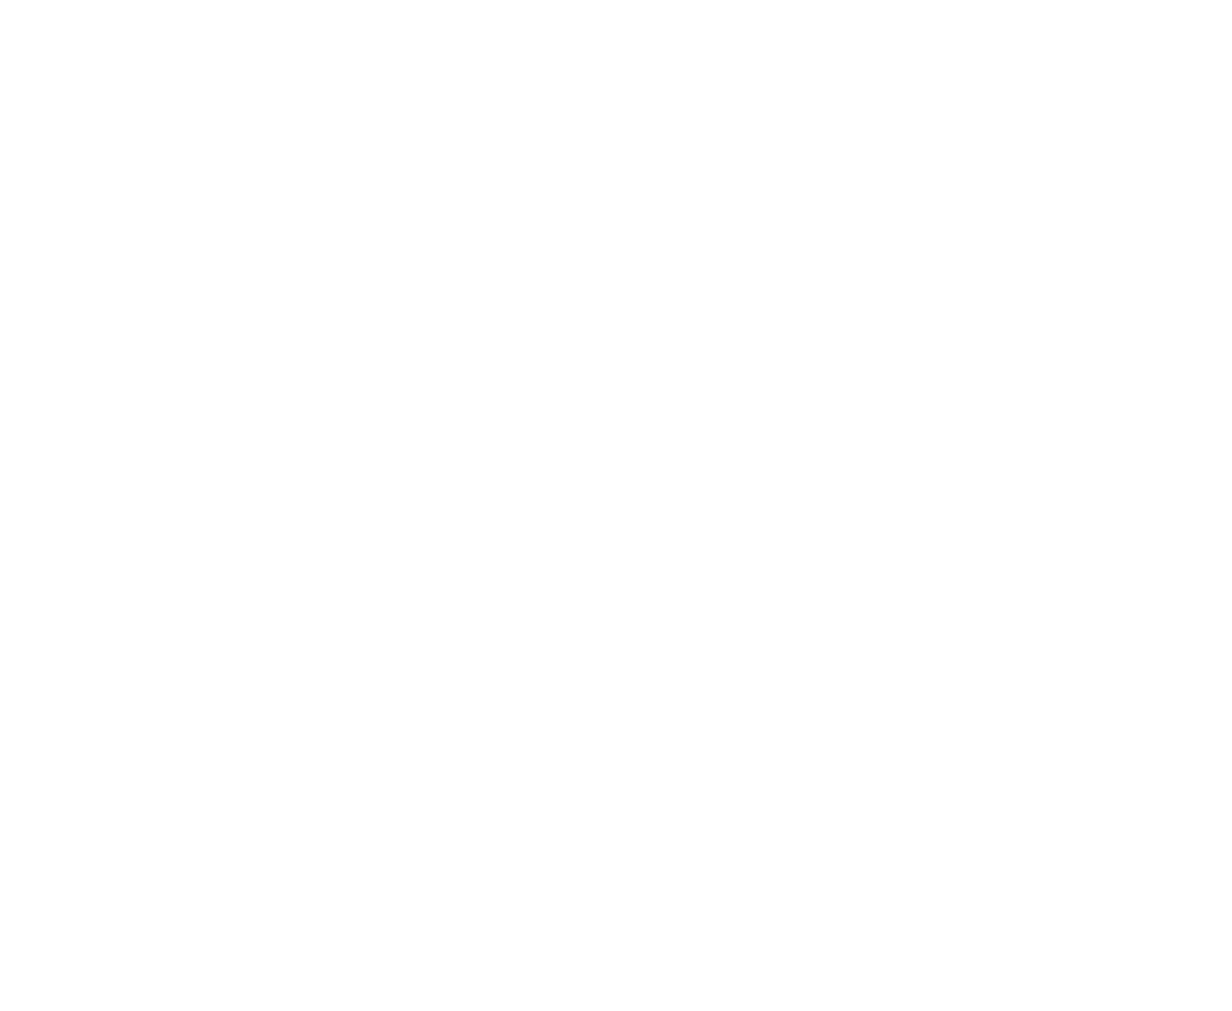

In [9]:
from sklearn.metrics import confusion_matrix

slot_dirs = [(slot, REC / slot) for slot in
             ('best_offline', 'best_transfer', 'best_low_fingerprint', 'recommended_firewall')
             if (REC / slot).exists()]

n = len(slot_dirs)
if n == 0:
    print('No recommended slots found.')
else:
    cols = min(n, 2); rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5.5 * cols, 4.5 * rows), squeeze=False)
    for ax, (slot, d) in zip(axes.flatten(), slot_dirs):
        pf = d / 'test_predictions.csv'
        tf = d / 'thresholds.json'
        if not pf.exists():
            ax.set_visible(False); continue
        df = pd.read_csv(pf)
        prob_col = next((c for c in ('prob', 'prob_cal', 'score', 'y_prob', 'p') if c in df.columns), None)
        y_col    = next((c for c in ('y_true', 'label', 'y') if c in df.columns), None)
        if prob_col is None or y_col is None:
            ax.set_visible(False); continue
        thr = 0.5
        if tf.exists():
            try:
                tj = json.loads(tf.read_text(encoding='utf-8'))
                thr = float(tj.get('flow_threshold',
                            tj.get('threshold',
                            tj.get('block_threshold', 0.5))))
            except Exception:
                pass
        pred = (df[prob_col] >= thr).astype(int)
        cm = confusion_matrix(df[y_col], pred, labels=[0, 1])
        im = ax.imshow(cm, cmap='Blues')
        for (i, j), v in np.ndenumerate(cm):
            ax.text(j, i, f'{v}', ha='center', va='center',
                    color='white' if v > cm.max() * 0.6 else 'black',
                    fontsize=11, fontweight='bold')
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(['nonVPN', 'VPN']); ax.set_yticklabels(['nonVPN', 'VPN'])
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{slot}\nthr={thr:.3f}')
    for ax in axes.flatten()[len(slot_dirs):]:
        ax.set_visible(False)
    plt.tight_layout(); plt.show()

## 9. Threshold stability across seeds

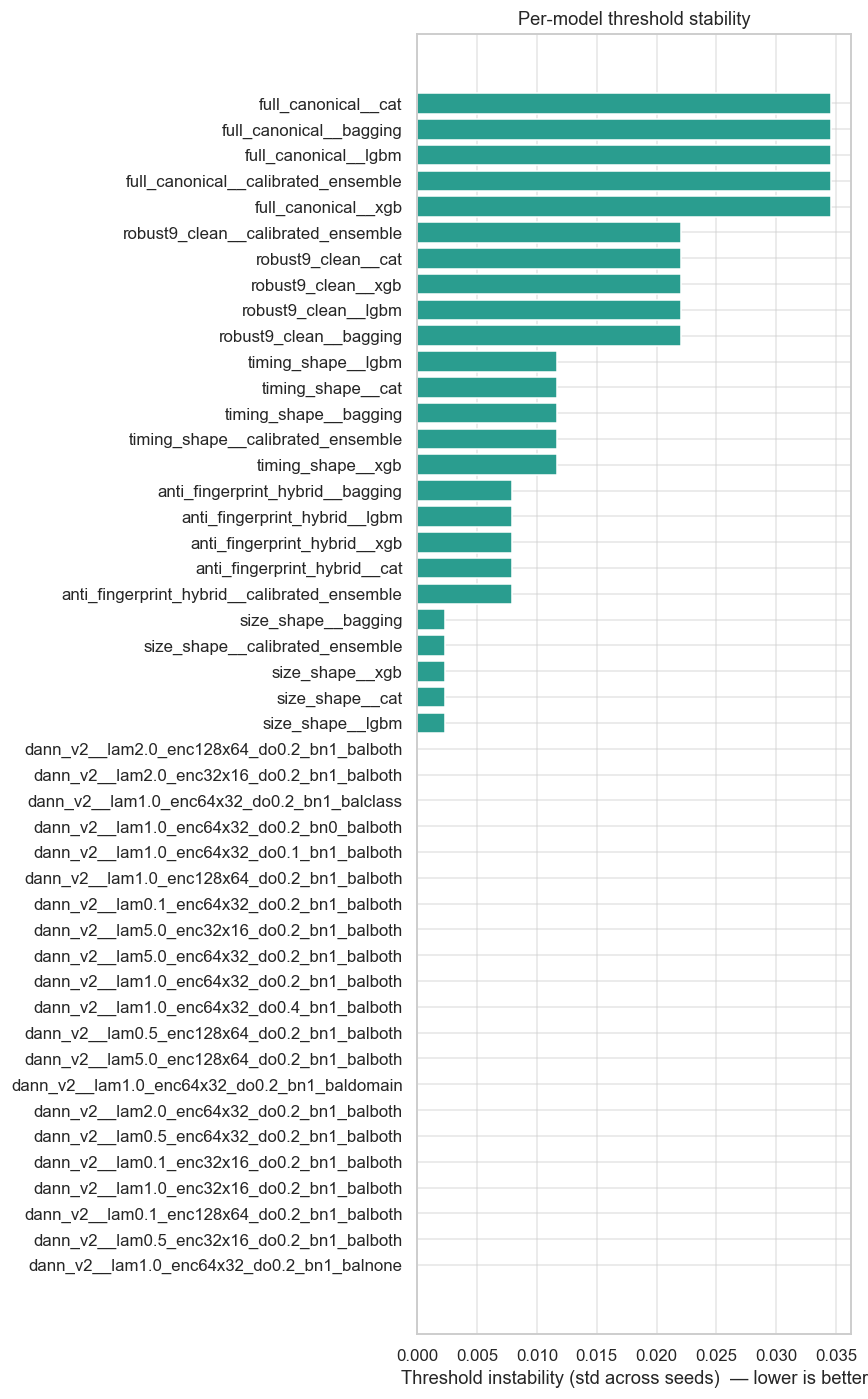

In [10]:
if 'threshold_instability' not in comp.columns:
    print('threshold_instability column missing')
else:
    d = comp.dropna(subset=['threshold_instability']).sort_values('threshold_instability', ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(d))))
    colors = ['#2a9d8f' if rc else '#e76f51' for rc in d['runtime_compatible']]
    ax.barh(d['model_id'], d['threshold_instability'], color=colors)
    ax.set_xlabel('Threshold instability (std across seeds)  — lower is better')
    ax.set_title('Per-model threshold stability')
    plt.tight_layout(); plt.show()

## 10. Anti-fingerprint feature score table

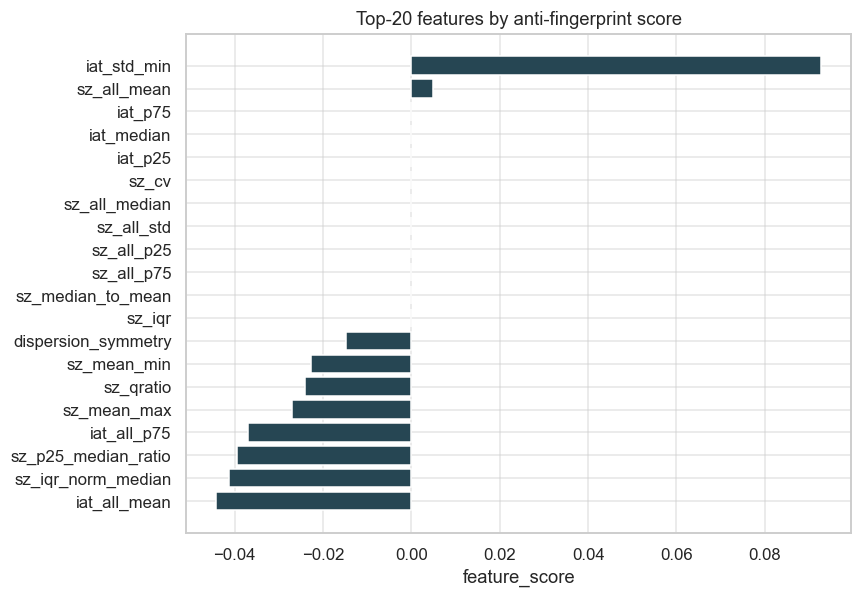

            feature  vpn_importance  domain_importance  instability_penalty  construction_penalty  feature_score
        iat_std_min          0.1118             0.0000               0.0636                   0.0         0.0928
        sz_all_mean          0.0050             0.0000               0.0000                   0.0         0.0050
            iat_p75          0.0000             0.0000               0.0000                   0.0         0.0000
         iat_median          0.0000             0.0000               0.0000                   0.0         0.0000
            iat_p25          0.0000             0.0000               0.0000                   0.0         0.0000
              sz_cv          0.0000             0.0000               0.0000                   0.0         0.0000
      sz_all_median          0.0000             0.0000               0.0000                   0.0         0.0000
         sz_all_std          0.0000             0.0000               0.0000                   0.

In [11]:
afp_path = ART / 'anti_fingerprint_scores.csv'
if not afp_path.exists():
    print('anti_fingerprint_scores.csv missing')
else:
    afp = pd.read_csv(afp_path)
    score_col = next((c for c in ('feature_score', 'score', 'final_score') if c in afp.columns), None)
    if score_col is None:
        print('no score column; have', list(afp.columns))
    else:
        afp = afp.sort_values(score_col, ascending=False).reset_index(drop=True)
        topk = afp.head(20)
        fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * len(topk))))
        ax.barh(topk['feature'][::-1], topk[score_col][::-1], color='#264653')
        ax.set_xlabel(score_col)
        ax.set_title('Top-20 features by anti-fingerprint score')
        plt.tight_layout(); plt.show()
        print(afp.head(20).round(4).to_string(index=False))

## 11. Final recommendation summary

In [12]:
rec_path = ART / 'recommended_models.json'
if not rec_path.exists():
    print('recommended_models.json missing')
else:
    rec = json.loads(rec_path.read_text(encoding='utf-8'))
    rows = []
    for slot, info in rec.items():
        d = dict(info)
        d.pop('metrics', None)
        d['slot'] = slot
        rows.append(d)
    summary = pd.DataFrame(rows)
    keep = [c for c in [
        'slot', 'model_id', 'feature_family', 'family', 'n_features',
        'pooled_auc', 'lodo_min_auc', 'lodo_mean_auc',
        'domain_auc', 'fpr', 'ece', 'threshold_instability',
        'runtime_compatible', 'final_score',
    ] if c in summary.columns]
    summary = summary[keep].set_index('slot')
    print('=== Recommended models ===')
    print(summary.round(4).to_string())
    fw = rec.get('recommended_firewall', {})
    print('\n>>> FIREWALL PROTOTYPE RECOMMENDATION <<<')
    print(f'  model_id            : {fw.get("model_id")}')
    print(f'  feature_family      : {fw.get("feature_family")}')
    print(f'  n_features          : {fw.get("n_features")}')
    print(f'  pooled_auc          : {fw.get("pooled_auc")}')
    print(f'  lodo_min_auc        : {fw.get("lodo_min_auc")}')
    print(f'  domain_auc          : {fw.get("domain_auc")}')
    print(f'  runtime_compatible  : {fw.get("runtime_compatible")}')
    print(f'  final_score         : {fw.get("final_score")}')

=== Recommended models ===
                                  model_id  feature_family family  n_features  pooled_auc  lodo_min_auc  lodo_mean_auc  domain_auc     fpr     ece  threshold_instability  runtime_compatible  final_score
slot                                                                                                                                                                                                      
best_offline          full_canonical__lgbm  full_canonical   lgbm          34      0.9994        0.6164         0.6531      1.0000  0.0025  0.0026                 0.0346                True       0.4336
best_transfer          full_canonical__xgb  full_canonical    xgb          34      0.9990        0.6164         0.6531      1.0000  0.0018  0.0046                 0.0346                True       0.4331
best_low_fingerprint    timing_shape__lgbm    timing_shape   lgbm           5      0.9423        0.4512         0.4756      0.9891  0.0040  0.0098               

## 12. DANN v2 — Architecture Verification & Domain Reduction
Visualises the improved DANN results from `artifacts/final_transfer/dann_v2/`.


In [13]:
dann_v2_path = ART / 'dann_v2' / 'dann_v2_results.csv'
if not dann_v2_path.exists():
    print('dann_v2_results.csv not found — run scripts/dann_improved.py first.')
    dann_v2 = pd.DataFrame()
else:
    dann_v2 = pd.read_csv(dann_v2_path)
    print(f'{len(dann_v2)} DANN v2 rows loaded.')
    show_cols = [c for c in [
        'model_id', 'dann_lambda', 'enc_hidden', 'dropout', 'balanced',
        'pooled_auc', 'input_domain_auc', 'embedding_domain_auc',
        'domain_reduction', 'lodo_min_auc', 'ece', 'final_score',
    ] if c in dann_v2.columns]
    dann_v2[show_cols].sort_values('final_score', ascending=False).head(20).round(4)

21 DANN v2 rows loaded.


### 12a. Lambda sweep — VPN AUC vs Embedding Domain AUC

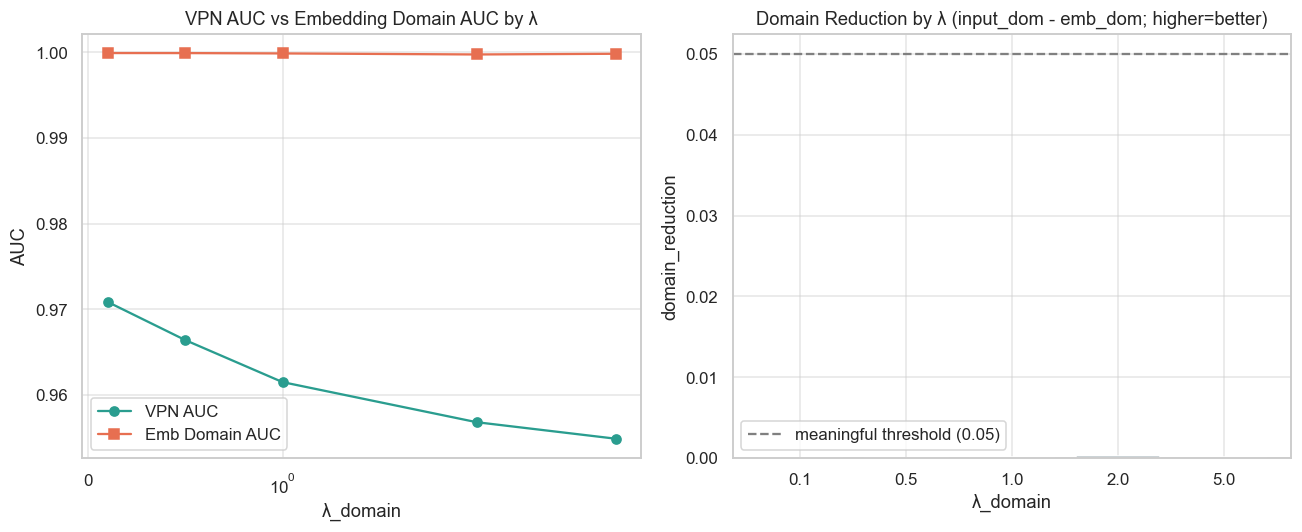

In [14]:
if not dann_v2.empty and 'dann_lambda' in dann_v2.columns:
    d = dann_v2.dropna(subset=['dann_lambda', 'pooled_auc', 'embedding_domain_auc'])
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    d_sorted = d.sort_values('dann_lambda')
    # group by lambda — take mean across arch variants
    by_lam = d_sorted.groupby('dann_lambda')[
        ['pooled_auc', 'embedding_domain_auc', 'domain_reduction']
    ].mean().reset_index()
    axes[0].plot(by_lam['dann_lambda'], by_lam['pooled_auc'],
                 marker='o', color='#2a9d8f', label='VPN AUC')
    axes[0].plot(by_lam['dann_lambda'], by_lam['embedding_domain_auc'],
                 marker='s', color='#e76f51', label='Emb Domain AUC')
    axes[0].set_xlabel('λ_domain'); axes[0].set_ylabel('AUC')
    axes[0].set_title('VPN AUC vs Embedding Domain AUC by λ')
    axes[0].legend(); axes[0].set_xscale('symlog')
    axes[1].bar(by_lam['dann_lambda'].astype(str), by_lam['domain_reduction'],
                color='#264653')
    axes[1].axhline(0.05, ls='--', color='grey', label='meaningful threshold (0.05)')
    axes[1].set_xlabel('λ_domain'); axes[1].set_ylabel('domain_reduction')
    axes[1].set_title('Domain Reduction by λ (input_dom - emb_dom; higher=better)')
    axes[1].legend(); plt.tight_layout(); plt.show()

### 12b. Input vs Embedding domain AUC scatter (all configs)

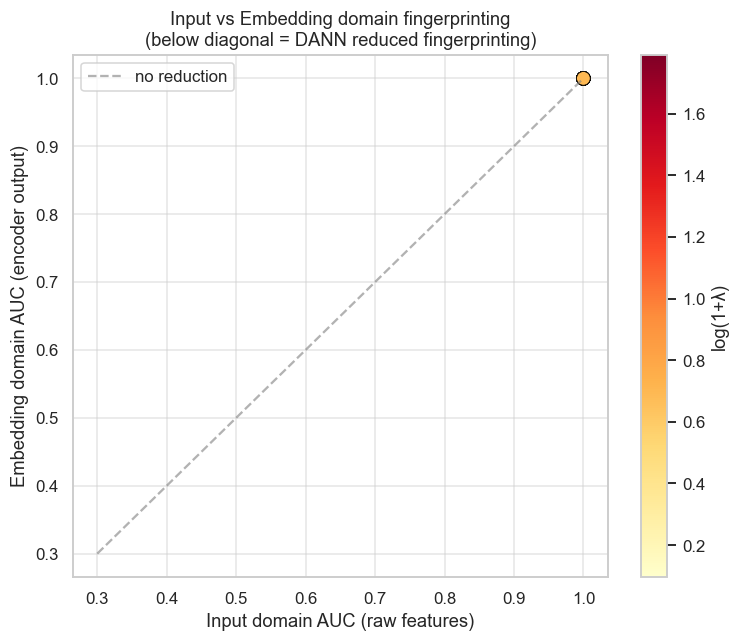

In [15]:
if not dann_v2.empty and 'embedding_domain_auc' in dann_v2.columns:
    d = dann_v2.dropna(subset=['input_domain_auc', 'embedding_domain_auc'])
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(d['input_domain_auc'], d['embedding_domain_auc'],
                    c=np.log1p(d['dann_lambda']),
                    cmap='YlOrRd', s=80, edgecolor='black', linewidth=0.5)
    ax.plot([0.3, 1.0], [0.3, 1.0], '--', color='grey', alpha=0.6, label='no reduction')
    ax.set_xlabel('Input domain AUC (raw features)')
    ax.set_ylabel('Embedding domain AUC (encoder output)')
    ax.set_title('Input vs Embedding domain fingerprinting\n(below diagonal = DANN reduced fingerprinting)')
    plt.colorbar(sc, ax=ax, label='log(1+λ)')
    ax.legend(); plt.tight_layout(); plt.show()

### 12c. DANN v2 training curves (best config)

Configs with training curves: 21


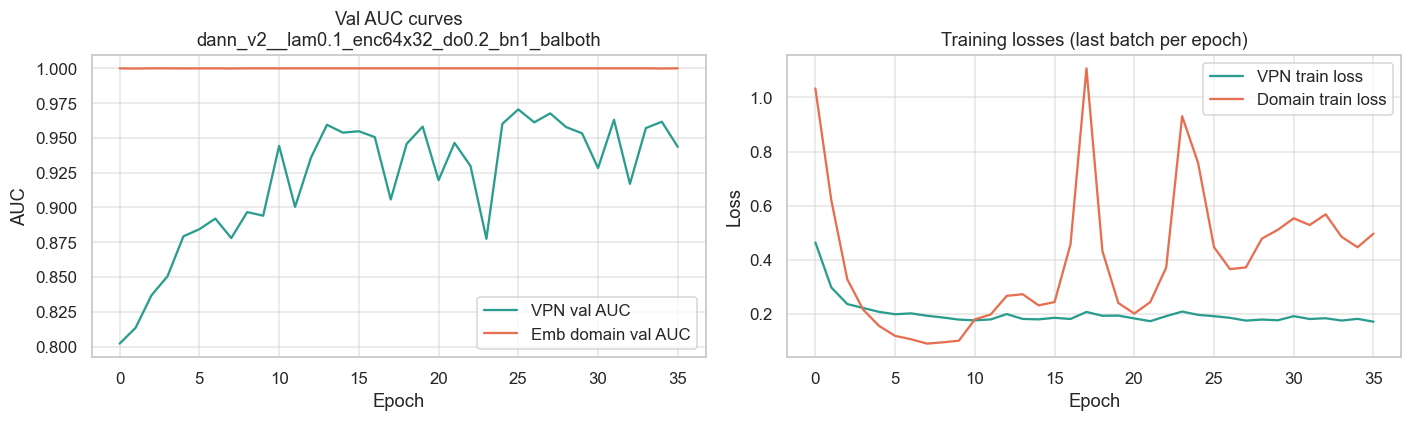


Showing curves for: dann_v2__lam0.1_enc64x32_do0.2_bn1_balboth


In [16]:
curves_path = ART / 'dann_v2' / 'dann_v2_training_curves.json'
if not curves_path.exists():
    print('Training curves not found.')
else:
    curves = json.loads(curves_path.read_text(encoding='utf-8'))
    print(f'Configs with training curves: {len(curves)}')
    # Plot best config (first one that has all keys)
    for cid, hist in curves.items():
        if all(k in hist for k in ('vpn_val_auc', 'emb_domain_val_auc',
                                    'vpn_train_loss', 'dom_train_loss')):
            fig, axes = plt.subplots(1, 2, figsize=(13, 4))
            ep = range(len(hist['vpn_val_auc']))
            axes[0].plot(ep, hist['vpn_val_auc'], label='VPN val AUC', color='#2a9d8f')
            axes[0].plot(ep, hist['emb_domain_val_auc'],
                         label='Emb domain val AUC', color='#e76f51')
            axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('AUC')
            axes[0].set_title(f'Val AUC curves\n{cid[:60]}')
            axes[0].legend()
            axes[1].plot(ep, hist['vpn_train_loss'],
                         label='VPN train loss', color='#2a9d8f')
            axes[1].plot(ep, hist['dom_train_loss'],
                         label='Domain train loss', color='#e76f51')
            axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
            axes[1].set_title('Training losses (last batch per epoch)')
            axes[1].legend()
            plt.tight_layout(); plt.show()
            print(f'\nShowing curves for: {cid}')
            break

### 12d. All training curves — multi-objective score trajectory

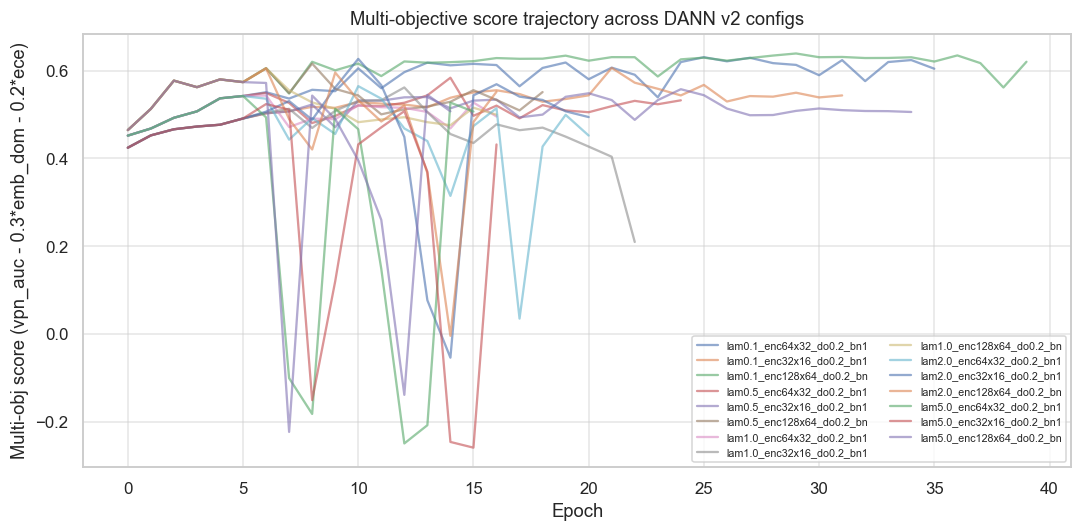

In [17]:
if curves_path.exists() and curves:
    fig, ax = plt.subplots(figsize=(10, 5))
    for cid, hist in list(curves.items())[:15]:   # top 15 to avoid clutter
        if 'multi_obj_score' in hist:
            ax.plot(hist['multi_obj_score'], alpha=0.6,
                    label=cid.split('__')[1][:25] if '__' in cid else cid[:25])
    ax.set_xlabel('Epoch'); ax.set_ylabel('Multi-obj score (vpn_auc - 0.3*emb_dom - 0.2*ece)')
    ax.set_title('Multi-objective score trajectory across DANN v2 configs')
    ax.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

### 12e. DANN v2 verdict

In [18]:
if not dann_v2.empty:
    best_red = dann_v2['domain_reduction'].max() if 'domain_reduction' in dann_v2.columns else 0
    best_dann = dann_v2.sort_values('final_score', ascending=False).iloc[0]
    print('=== DANN v2 Verdict ===')
    print(f'  Best domain_reduction:   {best_red:.4f}')
    print(f'  Best config:             {best_dann["model_id"]}')
    print(f'  pooled_auc:              {best_dann["pooled_auc"]:.4f}')
    if 'embedding_domain_auc' in best_dann.index:
        print(f'  embedding_domain_auc:    {best_dann["embedding_domain_auc"]:.4f}')
        print(f'  input_domain_auc:        {best_dann["input_domain_auc"]:.4f}')
    print(f'  final_score:             {best_dann["final_score"]:.4f}')
    if best_red > 0.05:
        verdict = 'SUCCESS — DANN reduced embedding domain fingerprinting'
    elif best_red > 0.01:
        verdict = 'MARGINAL — small reduction in embedding domain fingerprinting'
    else:
        verdict = ('NO MEANINGFUL REDUCTION — domain shift is structural '
                   '(consistent with NB51/52 findings)')
    print(f'\n  VERDICT: {verdict}')

=== DANN v2 Verdict ===
  Best domain_reduction:   0.0003
  Best config:             dann_v2__lam1.0_enc64x32_do0.2_bn1_balnone
  pooled_auc:              0.9787
  embedding_domain_auc:    0.9999
  input_domain_auc:        1.0000
  final_score:             0.9427

  VERDICT: NO MEANINGFUL REDUCTION — domain shift is structural (consistent with NB51/52 findings)
